# PE2 Stage 6: baseline model development
Compare four classifiers and their imbalance-aware variants for occupancy counts 0, 1, 2 and 3. Use only PE1 training rows, four identical temporal-group folds, and macro F1 as the main metric. The final 2017/12/23 session is not evaluated here.

Run from the project root or `notebooks/` using the project Python environment.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.pe2_transformers import SoundTertileEncoder

DATA = ROOT / "data/pe1_preprocessing"
RESULTS = ROOT / "results/pe2"
FIGURES = RESULTS / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
SEED, CLASSES, TEST_DATE = 42, [0, 1, 2, 3], "2017/12/23"
TARGET = "Room_Occupancy_Count"

## 1. Load PE1 training data

In [2]:
X_train = pd.read_csv(DATA / "X_train.csv")
y_train = pd.read_csv(DATA / "y_train.csv")[TARGET]
prepared = pd.read_csv(DATA / "Occupancy_Estimation_prepared.csv")
training_rows = prepared.loc[prepared["Session_Date"] != TEST_DATE].reset_index(drop=True)
del prepared

# Remove the old sound category so each training fold can create its own.
X = X_train.drop(columns="Sound_Level_Code")
dates = training_rows["Session_Date"]
minutes = training_rows["Time_of_Day_Minutes"]

## 2. Verify the data
The exported rows must match the prepared training sessions. Class 0 dominates, so high accuracy alone can hide mistakes on occupied rooms.

In [3]:
assert X_train.shape == (7350, 13) and len(y_train) == len(training_rows) == 7350
assert set(y_train) == set(CLASSES)
assert not X.isna().any().any() and not y_train.isna().any()
assert not {"Session_Date", "Temporal_Block", TARGET}.intersection(X.columns)
assert np.allclose(X_train, training_rows[X_train.columns])
assert np.array_equal(y_train, training_rows[TARGET])
print("Training shape:", X_train.shape)
display(y_train.value_counts().sort_index().rename("rows").to_frame())
print(f"Always predicting class 0 would achieve {(y_train == 0).mean():.2%} accuracy.")

Training shape: (7350, 13)


,rows
Room_Occupancy_Count,
0,6231
1,205
2,350
3,564


Always predicting class 0 would achieve 84.78% accuracy.


## 3. Create 30-minute temporal blocks
Nearby 30-second readings can be almost identical. Keep each date/half-hour block together. Whole-date grouping would remove class 1 from some training folds because it appears in only one training session.

In [4]:
groups = dates + "_" + np.floor(minutes / 30).astype(int).astype(str)
print("Temporal blocks:", groups.nunique())

Temporal blocks: 132


## 4. Create the four CV folds
Every experiment uses these same folds. Blocks reduce overlap between nearby rows, but adjacent blocks and observations from the same session can still be correlated. This is within-session block validation, not forward-chaining or a new-day evaluation.

In [5]:
cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=SEED)
splits = list(cv.split(X, y_train, groups))
fold_counts = []
for fold, (train_idx, valid_idx) in enumerate(splits, 1):
    assert not set(groups.iloc[train_idx]).intersection(groups.iloc[valid_idx])
    for part, idx in [("train", train_idx), ("validation", valid_idx)]:
        counts = y_train.iloc[idx].value_counts().reindex(CLASSES, fill_value=0)
        assert (counts > 0).all()
        fold_counts.append([fold, part, *counts.tolist()])
display(pd.DataFrame(fold_counts, columns=["fold", "part", "class_0", "class_1", "class_2", "class_3"]))

,fold,part,class_0,class_1,class_2,class_3
0,1,train,4649,144,245,426
1,1,validation,1582,61,105,138
2,2,train,4687,151,286,427
3,2,validation,1544,54,64,137
4,3,train,4681,145,253,423
5,3,validation,1550,60,97,141
6,4,train,4676,175,266,416
7,4,validation,1555,30,84,148


## 5. Define four suitable models
Logistic Regression is a simple linear reference; KNN compares similar sensor profiles; Random Forest learns sensor interactions; RBF SVC learns a nonlinear boundary.

The shared `SoundTertileEncoder` learns sound tertiles inside each training fold and keeps continuous `Avg_Sound`. Fixed CO2 bands stay unchanged. Logistic Regression, KNN and SVC also scale inside their pipelines so CO2/light units do not dominate. RF uses tree thresholds and does not need scaling. The pre-scaled PE1 export is not used.

In [6]:
def scaled_model(classifier):
    return Pipeline([
        ("sound", SoundTertileEncoder()), ("scale", StandardScaler()), ("model", classifier)
    ])

baselines = {
    "Logistic Regression - baseline": scaled_model(LogisticRegression(max_iter=5000, random_state=SEED)),
    "KNN - baseline": scaled_model(KNeighborsClassifier()),
    "Random Forest - baseline": Pipeline([
        ("sound", SoundTertileEncoder()),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)),
    ]),
    "SVC - baseline": scaled_model(SVC(kernel="rbf", random_state=SEED)),
}

## 6. Evaluate the normal baselines
One short evaluation function avoids repeating the four-fold loop for eight models. Each training fold fits a fresh pipeline; its validation predictions also form the out-of-fold (OOF) report.

Macro F1 gives each occupancy count equal weight. Balanced accuracy equals macro recall here. Weighted F1 and accuracy reflect the large class-0 population. The comparison uses mean fold scores and sample SD (ddof=1); per-class recall uses pooled OOF predictions.

In [7]:
def metrics(truth, prediction):
    return {
        "accuracy": accuracy_score(truth, prediction),
        "balanced_accuracy": balanced_accuracy_score(truth, prediction),
        "macro_precision": precision_score(truth, prediction, average="macro", zero_division=0),
        "macro_recall": recall_score(truth, prediction, average="macro", zero_division=0),
        "macro_f1": f1_score(truth, prediction, average="macro", zero_division=0),
        "weighted_f1": f1_score(truth, prediction, average="weighted", zero_division=0),
    }

def evaluate_model(name, pipeline):
    predictions = np.zeros(len(y_train), dtype=int)
    fold_scores = []
    for train_idx, valid_idx in splits:
        fitted = clone(pipeline).fit(X.iloc[train_idx], y_train.iloc[train_idx])
        prediction = fitted.predict(X.iloc[valid_idx])
        predictions[valid_idx] = prediction
        fold_scores.append(metrics(y_train.iloc[valid_idx], prediction))
    scores = pd.DataFrame(fold_scores)
    report = classification_report(y_train, predictions, labels=CLASSES, output_dict=True, zero_division=0)
    row = {
        "experiment": name,
        **{f"cv_mean_{m}": scores[m].mean() for m in scores},
        "cv_std_macro_f1": scores["macro_f1"].std(ddof=1),
        "oof_macro_f1": f1_score(y_train, predictions, average="macro"),
        **{f"class_{c}_recall": report[str(c)]["recall"] for c in CLASSES},
    }
    return row, predictions

rows, predictions = [], {}
for name, pipeline in baselines.items():
    row, predictions[name] = evaluate_model(name, pipeline)
    rows.append(row)
display(pd.DataFrame(rows).round(4))

,experiment,cv_mean_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_precision,cv_mean_macro_recall,cv_mean_macro_f1,cv_mean_weighted_f1,cv_std_macro_f1,oof_macro_f1,class_0_recall,class_1_recall,class_2_recall,class_3_recall
0,Logistic Regression - baseline,0.9506,0.7570,0.7984,0.7570,0.7483,0.9466,0.1201,0.7809,0.9960,0.8098,0.6114,0.7128
1,KNN - baseline,0.9613,0.8120,0.8249,0.8120,0.8107,0.9600,0.0404,0.8221,0.9970,0.8390,0.6229,0.8227
2,Random Forest - baseline,0.9655,0.8585,0.9005,0.8585,0.8657,0.9639,0.0344,0.8726,0.9973,0.9707,0.7343,0.7535
3,SVC - baseline,0.9588,0.8412,0.8668,0.8412,0.8224,0.9565,0.0654,0.8464,0.9883,0.9512,0.6657,0.8156


## 7. Test class-imbalance approaches
Class weights make minority errors more costly. RF uses `balanced_subsample`; Logistic Regression and SVC use `balanced`.

KNN has no class weights, so its variant uses RandomOverSampler **inside** an imbalanced-learn pipeline. Only training rows are duplicated. Validation rows keep their original distribution. Duplication preserves binary/ordinal sensor values, unlike synthetic interpolation. Sound encoding and scaling are fitted before resampling.

In [8]:
imbalance_models = {
    "Logistic Regression - balanced": scaled_model(
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=SEED)),
    "KNN - RandomOverSampler": ImbPipeline([
        ("sound", SoundTertileEncoder()), ("scale", StandardScaler()),
        ("oversample", RandomOverSampler(random_state=SEED)), ("model", KNeighborsClassifier()),
    ]),
    "Random Forest - balanced": Pipeline([
        ("sound", SoundTertileEncoder()),
        ("model", RandomForestClassifier(n_estimators=100, class_weight="balanced_subsample",
                                         random_state=SEED, n_jobs=-1)),
    ]),
    "SVC - balanced": scaled_model(SVC(kernel="rbf", class_weight="balanced", random_state=SEED)),
}
for name, pipeline in imbalance_models.items():
    row, predictions[name] = evaluate_model(name, pipeline)
    rows.append(row)

## 8. Compare results
Keep one comparison CSV. The notebooks retain the detailed reports and confusion matrices; extra prediction dumps and repeated summary files are unnecessary.

,experiment,cv_mean_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_precision,cv_mean_macro_recall,cv_mean_macro_f1,cv_mean_weighted_f1,cv_std_macro_f1,oof_macro_f1,class_0_recall,class_1_recall,class_2_recall,class_3_recall,minority_min_recall
0,Random Forest - baseline,0.9655,0.8585,0.9005,0.8585,0.8657,0.9639,0.0344,0.8726,0.9973,0.9707,0.7343,0.7535,0.7343
1,Random Forest - balanced,0.9628,0.8226,0.9042,0.8226,0.8415,0.9598,0.0395,0.8522,0.9995,0.8146,0.7171,0.7606,0.7171
2,SVC - baseline,0.9588,0.8412,0.8668,0.8412,0.8224,0.9565,0.0654,0.8464,0.9883,0.9512,0.6657,0.8156,0.6657
3,SVC - balanced,0.9574,0.8628,0.8543,0.8628,0.8223,0.9558,0.0623,0.8482,0.9819,0.9756,0.7543,0.8050,0.7543
4,KNN - RandomOverSampler,0.9635,0.8363,0.8340,0.8363,0.8215,0.9618,0.0598,0.8391,0.9960,0.8976,0.7000,0.7926,0.7000
5,KNN - baseline,0.9613,0.8120,0.8249,0.8120,0.8107,0.9600,0.0404,0.8221,0.9970,0.8390,0.6229,0.8227,0.6229
6,Logistic Regression - baseline,0.9506,0.7570,0.7984,0.7570,0.7483,0.9466,0.1201,0.7809,0.9960,0.8098,0.6114,0.7128,0.6114
7,Logistic Regression - balanced,0.9460,0.7844,0.7969,0.7844,0.7330,0.9419,0.1085,0.7685,0.9907,0.9024,0.6486,0.6543,0.6486


Random Forest - baseline
              precision    recall  f1-score   support

           0     0.9909    0.9973    0.9941      6231
           1     0.9950    0.9707    0.9827       205
           2     0.7449    0.7343    0.7396       350
           3     0.7959    0.7535    0.7741       564

    accuracy                         0.9653      7350
   macro avg     0.8817    0.8640    0.8726      7350
weighted avg     0.9643    0.9653    0.9648      7350

Random Forest - balanced
              precision    recall  f1-score   support

           0     0.9856    0.9995    0.9925      6231
           1     1.0000    0.8146    0.8978       205
           2     0.7538    0.7171    0.7350       350
           3     0.8079    0.7606    0.7836       564

    accuracy                         0.9626      7350
   macro avg     0.8868    0.8230    0.8522      7350
weighted avg     0.9613    0.9626    0.9616      7350

SVC - baseline
              precision    recall  f1-score   support

          

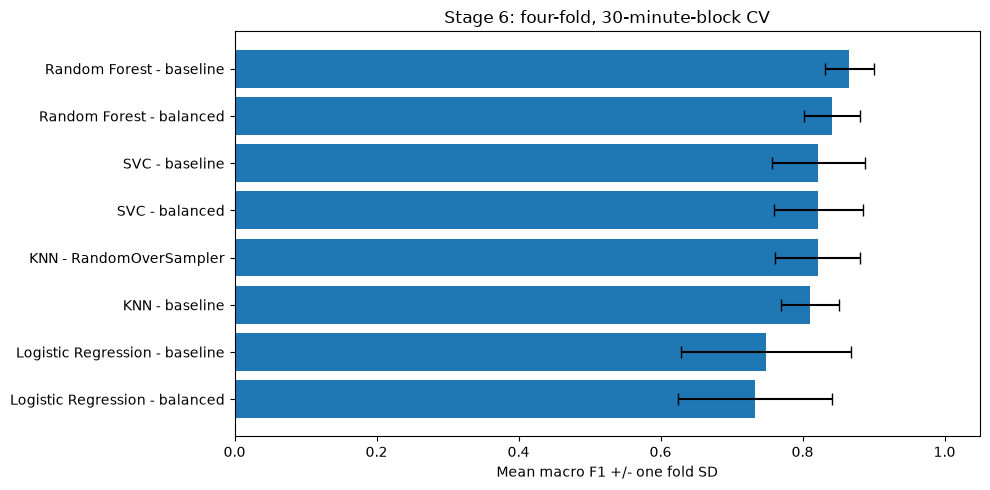

In [9]:
results = pd.DataFrame(rows)
results["minority_min_recall"] = results[["class_1_recall", "class_2_recall", "class_3_recall"]].min(axis=1)
results = results.sort_values("cv_mean_macro_f1", ascending=False).reset_index(drop=True)
results.to_csv(RESULTS / "baseline_model_comparison.csv", index=False)
display(results.round(4))

for name in results["experiment"]:
    print(name)
    print(classification_report(y_train, predictions[name], labels=CLASSES, digits=4, zero_division=0))

plot_data = results.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_data["experiment"], plot_data["cv_mean_macro_f1"],
        xerr=plot_data["cv_std_macro_f1"], capsize=4)
ax.set(xlabel="Mean macro F1 +/- one fold SD", xlim=(0, 1.05),
       title="Stage 6: four-fold, 30-minute-block CV")
fig.tight_layout()
fig.savefig(FIGURES / "macro_f1_comparison.png", dpi=160)
plt.show()
plt.close(fig)

**Observed trade-offs.** RF baseline leads on macro F1 (0.8657). RF weighting lowers macro F1 to 0.8415 and class-1 recall from 0.9707 to 0.8146. Balanced SVC has almost unchanged macro F1 (0.8223 versus 0.8224), but improves balanced accuracy and class-2 recall.

KNN oversampling raises macro F1 from 0.8107 to 0.8215, with better class-1/2 recall but lower class-3 recall. Balanced Logistic Regression also gains recall for counts 1/2 while losing class-3 recall and macro F1. Imbalance handling is therefore model-dependent, not an automatic improvement.

## 9. Select RF and SVC for Stage 7
Carry **baseline Random Forest** forward for its macro F1 and stability, and **balanced SVC** for its stronger occupied-class recalls. Weighted RF ranks second on macro F1, but its weaker minority recall makes balanced SVC a useful complementary approach.

The class-2 recalls of these candidates are 0.7343 and 0.7543; class 2 is their weakest occupied count. SVC recovers more occupied observations but creates more empty-room false alarms. The matrices below show that trade-off.

No tuning or final test evaluation happens in Stage 6.

,cv_mean_accuracy,cv_mean_balanced_accuracy,cv_mean_macro_precision,cv_mean_macro_recall,cv_mean_macro_f1,cv_mean_weighted_f1,cv_std_macro_f1,oof_macro_f1,class_0_recall,class_1_recall,class_2_recall,class_3_recall,minority_min_recall
experiment,,,,,,,,,,,,,
Random Forest - baseline,0.9655,0.8585,0.9005,0.8585,0.8657,0.9639,0.0344,0.8726,0.9973,0.9707,0.7343,0.7535,0.7343
SVC - balanced,0.9574,0.8628,0.8543,0.8628,0.8223,0.9558,0.0623,0.8482,0.9819,0.9756,0.7543,0.8050,0.7543


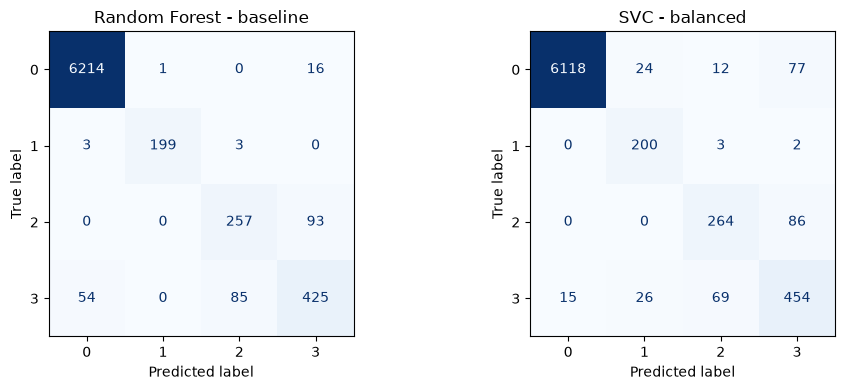

Stage 7 candidates: Random Forest - baseline, SVC - balanced
The held-out 2017/12/23 test session is not evaluated in this notebook.


In [10]:
candidate_names = ["Random Forest - baseline", "SVC - balanced"]
display(results.set_index("experiment").loc[candidate_names].round(4))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, candidate_names):
    ConfusionMatrixDisplay.from_predictions(y_train, predictions[name], labels=CLASSES,
                                            ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
fig.tight_layout()
plt.show()
plt.close(fig)
print("Stage 7 candidates:", ", ".join(candidate_names))
print("The held-out 2017/12/23 test session is not evaluated in this notebook.")